# Angriness Predictor v3 — Leak-Free Splits + External (Next-Game) Validation

This notebook documents the **corrected** angriness / tilt pipeline. It is a two-stage,
semi-supervised model on ~25k real Lichess games:

1. **Stage 1 — Isolation Forest** scores how anomalous each game is and we bucket those
   scores into 5 angriness levels by percentile (the labels).
2. **Stage 2 — Random Forest** is trained to reproduce those labels from the raw behavioral
   features (a fast surrogate that does not need the IF at inference).

**What changed vs v2 (two fixes):**

- **Leak fix.** v2 fit the `StandardScaler` (and IQR bounds / imputation) on the *full*
  dataset *before* the train/val/test split. v3 **splits first** and fits every transform on
  **train only**.
- **Non-circular validation.** v2 only checked that angriness correlates with ACPL / blunders
  / consecutive losses — the very features the Isolation Forest used to build the labels, so
  the check could not fail. v3 adds an **external** check: does a high-angriness game predict
  a worse result in the player's **next** game? Next-game rating change (`elo_diff`) is never
  an IF input, so this is independent.

In [475]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Work whether the notebook runs from the trainer dir or the notebooks/ dir.
BASE = Path.cwd()
if not (BASE / "data").exists() and (BASE.parent / "data").exists():
    BASE = BASE.parent
PROCESSED = BASE / "data" / "processed"
print("Base dir:", BASE)

RANDOM_STATE = 42
FEATURE_ORDER = [
    "consecutive_losses_pregame", "avg_tpm_seconds_player", "blunder_cnt_player",
    "mistake_cnt_player", "inaccuracy_cnt_player", "acpl_player", "accuracy_player", "elo",
]
IQR_MULTIPLIER = 1.5
PERCENTILE_EDGES = [0, 10, 35, 65, 90, 100]

# Where diagnostic plots are written (notebooks/plots, matches v2).
PLOT_DIR = Path.cwd() / "plots"
PLOT_DIR.mkdir(exist_ok=True)
LEVEL_LABELS = {1: "Calm", 2: "Mild", 3: "Neutral", 4: "Annoyed", 5: "Tilted"}
LEVEL_COLORS = ["#2ecc71", "#a8e6cf", "#f9e79f", "#f5b041", "#e74c3c"]

Base dir: c:\swe_repos\my-portfolio-and-vps-repos\Chess-Assistance\machine_learning\trainers\trainer-angriness-predictor


## Step 1 — Data Gathering

Load the validated dataset (real Lichess games, ~150 players across five ELO brackets, with
Lichess's own computer-analysis ACPL / blunder / accuracy figures). `1_gather.py` already
dropped rows with missing analysis.

In [476]:
df = pd.read_csv(PROCESSED / "raw_validated.csv")
print("Shape:", df.shape)

bins = [0, 1200, 1600, 2000, 2400, 5000]
labels = ["800-1200", "1200-1600", "1600-2000", "2000-2400", "2400+"]
print("\nELO distribution:")
print(pd.cut(df["elo"], bins=bins, labels=labels).value_counts().sort_index().to_string())
df[FEATURE_ORDER].describe().round(2)

Shape: (25249, 28)

ELO distribution:
elo
800-1200     1287
1200-1600    6000
1600-2000    6000
2000-2400    5962
2400+        6000


,consecutive_losses_pregame,avg_tpm_seconds_player,blunder_cnt_player,mistake_cnt_player,inaccuracy_cnt_player,acpl_player,accuracy_player,elo
count,25249.00,25249.00,25249.00,25249.00,25249.00,25249.00,25249.00,25249.00
mean,0.31,15.40,2.08,1.35,3.23,56.15,35.71,2041.12
std,0.77,12.15,2.08,1.41,2.43,37.01,35.63,621.34
min,0.00,0.08,0.00,0.00,0.00,0.00,0.00,800.00
25%,0.00,4.79,1.00,0.00,1.00,30.00,2.70,1568.00
50%,0.00,14.11,2.00,1.00,3.00,49.00,19.30,1940.00
75%,0.00,22.51,3.00,2.00,5.00,73.00,76.00,2349.00
max,20.00,99.41,22.00,12.00,43.00,550.00,100.00,3483.00


## Step 2 — Feature Selection

Eight features: 7 behavioral tilt indicators + ELO. **Note:** unlike v2 we do **not** scale or
remove outliers here — those are fit-on-train operations and must happen *after* the split
(Step 3), otherwise validation/test statistics leak into preprocessing. Here we only inspect
the raw distributions.

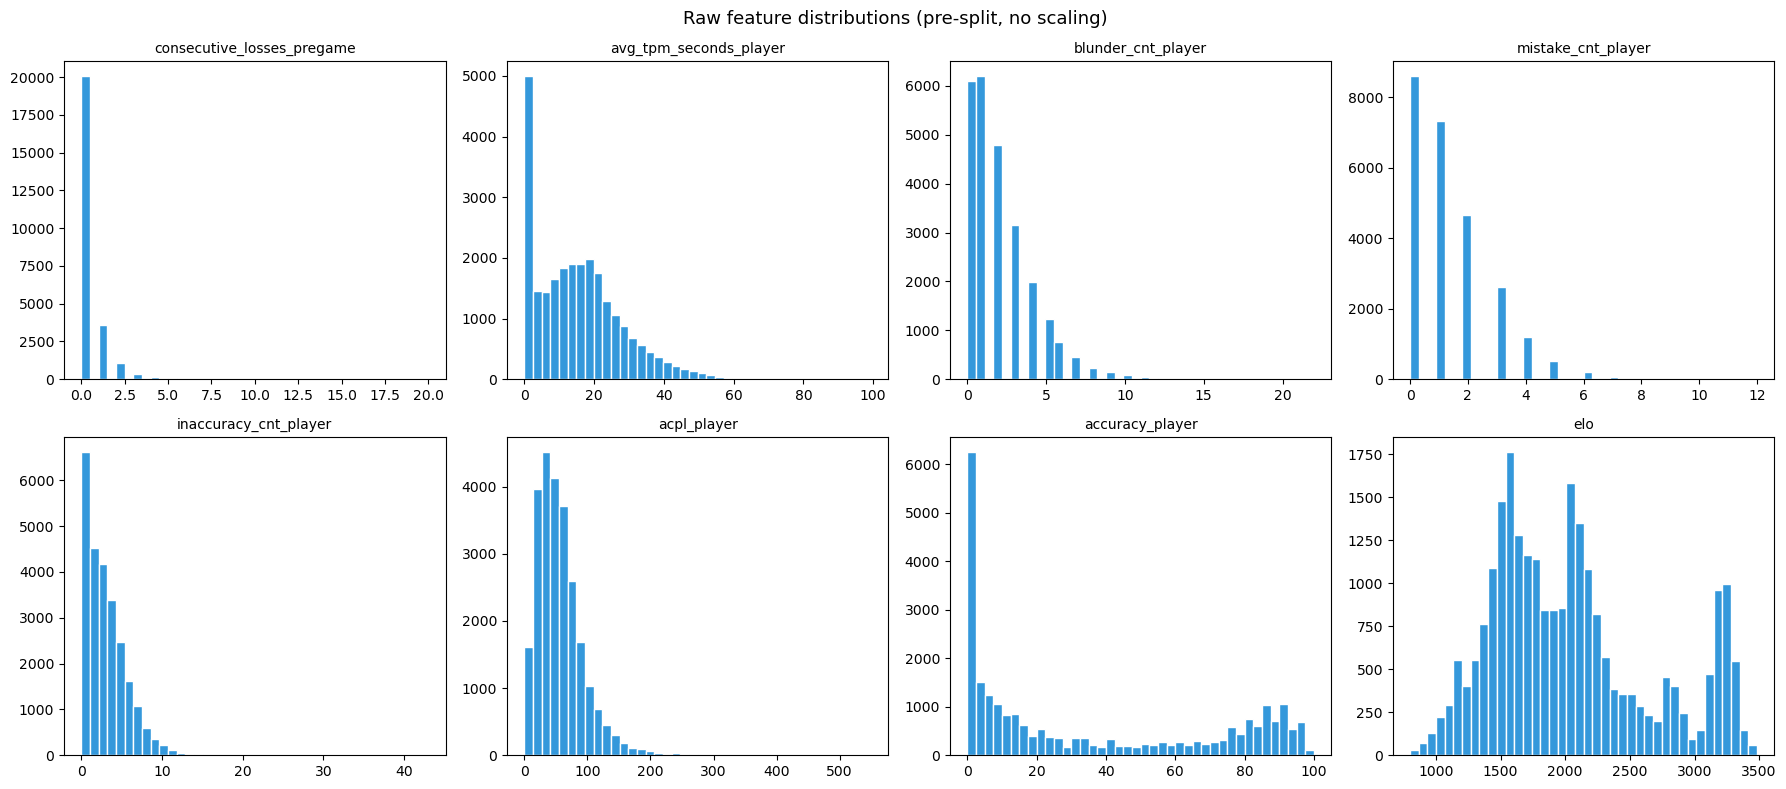

In [477]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), FEATURE_ORDER):
    ax.hist(df[col].dropna(), bins=40, color="#3498db", edgecolor="white")
    ax.set_title(col, fontsize=10)
fig.suptitle("Raw feature distributions (pre-split, no scaling)", fontsize=13)
plt.tight_layout()
plt.show()

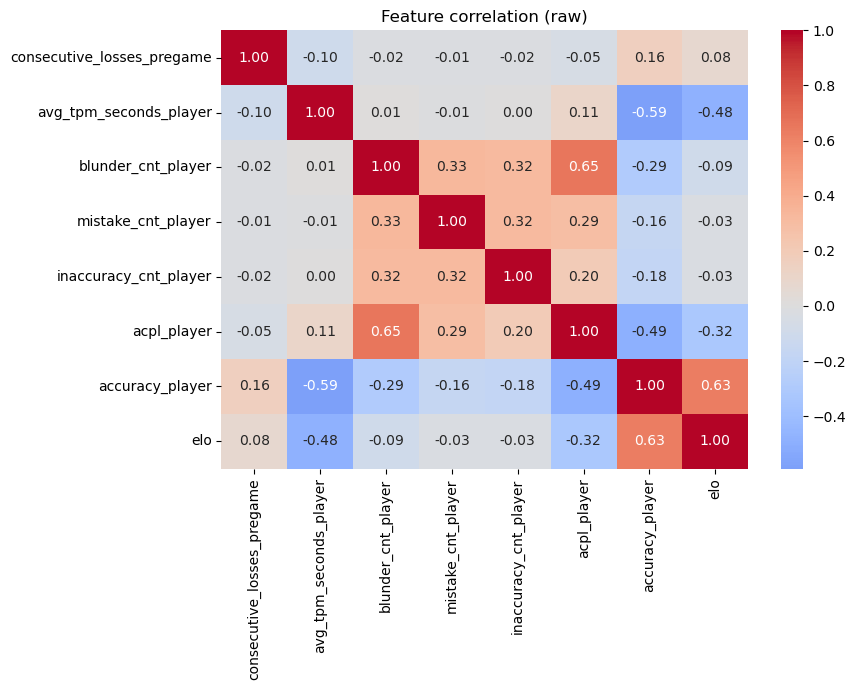

In [478]:
corr = df[FEATURE_ORDER].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Feature correlation (raw)")
plt.tight_layout()
plt.show()

## Step 3 — Training (split first, fit on train only)

This is the **leak fix**. We split into train/val/test *first* (two-stage 64/16/20,
`random_state=42`), then fit median-imputation, IQR outlier bounds and the `StandardScaler`
on **train only** and apply them to val/test. Outliers are dropped from **train only** — we
never drop evaluation rows.

In [479]:
idx = np.arange(len(df))
trainval_idx, test_idx = train_test_split(idx, test_size=0.20, random_state=RANDOM_STATE)
train_idx, val_idx = train_test_split(trainval_idx, test_size=0.20, random_state=RANDOM_STATE)
print(f"Split -> train {len(train_idx)} / val {len(val_idx)} / test {len(test_idx)}")

# Fit medians, IQR bounds and scaler on TRAIN only
train_feat = df.iloc[train_idx][FEATURE_ORDER].copy()
medians = train_feat.median()
train_feat = train_feat.fillna(medians)

bounds = {}
for col in FEATURE_ORDER:
    q1, q3 = train_feat[col].quantile(0.25), train_feat[col].quantile(0.75)
    iqr = q3 - q1
    bounds[col] = (q1 - IQR_MULTIPLIER * iqr, q3 + IQR_MULTIPLIER * iqr) if iqr else (None, None)

def keep_mask(frame):
    m = pd.Series(True, index=frame.index)
    for c, (lo, hi) in bounds.items():
        if hi is None:
            continue
        m &= (frame[c] >= lo) & (frame[c] <= hi)
    return m

keep_train = keep_mask(train_feat)
scaler = StandardScaler().fit(train_feat.loc[keep_train, FEATURE_ORDER])
print(f"Train outliers removed: {int((~keep_train).sum())}; scaler fit on {int(keep_train.sum())} rows")

def build(pos_idx, drop_outliers):
    feat = df.iloc[pos_idx][FEATURE_ORDER].copy().fillna(medians)
    raw = df.iloc[pos_idx].copy()
    raw[FEATURE_ORDER] = raw[FEATURE_ORDER].fillna(medians)
    if drop_outliers:
        k = keep_mask(feat)
        feat, raw = feat.loc[k], raw.loc[k]
    scaled = pd.DataFrame(scaler.transform(feat[FEATURE_ORDER]), columns=FEATURE_ORDER, index=feat.index)
    return scaled.reset_index(drop=True), raw.reset_index(drop=True)

feat_train, raw_train = build(train_idx, True)
feat_val, raw_val = build(val_idx, False)
feat_test, raw_test = build(test_idx, False)
print(f"Final rows -> train {len(feat_train)} / val {len(feat_val)} / test {len(feat_test)}")

Split -> train 16159 / val 4040 / test 5050
Train outliers removed: 1476; scaler fit on 14683 rows
Final rows -> train 14683 / val 4040 / test 5050


In [480]:
# Stage 1: Isolation Forest -> percentile bins -> angriness labels (TRAIN)
if_model = IsolationForest(contamination=0.03, n_estimators=200, max_features=0.75,
                           random_state=42).fit(feat_train[FEATURE_ORDER].values)
scores_train = if_model.decision_function(feat_train[FEATURE_ORDER].values)
bin_edges = [float(np.percentile(scores_train, p)) for p in PERCENTILE_EDGES]

def score_to_angriness(s, edges):
    for i in range(len(edges) - 1):
        if s <= edges[i + 1]:
            return 5 - i
    return 1

y_train = np.array([score_to_angriness(s, bin_edges) for s in scores_train])
print("Bin edges:", [round(e, 4) for e in bin_edges])
print("Train angriness distribution:")
for lvl in range(1, 6):
    print(f"  Level {lvl}: {(y_train == lvl).sum()}")

Bin edges: [-0.0967, 0.0319, 0.0781, 0.1081, 0.1369, 0.1695]
Train angriness distribution:
  Level 1: 1469
  Level 2: 3670
  Level 3: 4405
  Level 4: 3670
  Level 5: 1469


In [481]:
# Stage 2: Random Forest surrogate on UNSCALED train features
rf = RandomForestClassifier(n_estimators=200, max_depth=9, min_samples_leaf=9,
                            min_samples_split=10, max_features="sqrt",
                            random_state=42, n_jobs=-1)
rf.fit(raw_train[FEATURE_ORDER].values, y_train)
print("Train accuracy vs IF labels:", round((rf.predict(raw_train[FEATURE_ORDER].values) == y_train).mean(), 4))

Train accuracy vs IF labels: 0.7432


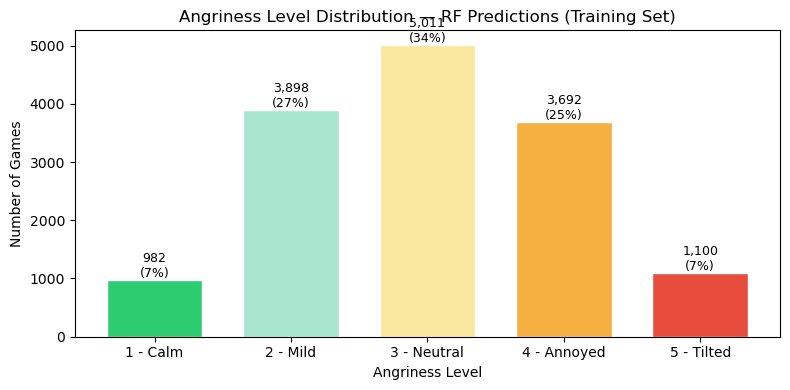

In [482]:
rf_pred_train = rf.predict(raw_train[FEATURE_ORDER].values)

level_counts = pd.Series(rf_pred_train).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(level_counts.index, level_counts.values,
              color=[LEVEL_COLORS[i - 1] for i in level_counts.index],
              edgecolor="white", width=0.7)
for bar, count in zip(bars, level_counts.values):
    pct = count / len(rf_pred_train) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f"{count:,}\n({pct:.0f}%)", ha="center", fontsize=9)
ax.set_xticks(level_counts.index)
ax.set_xticklabels([f"{lvl} - {LEVEL_LABELS[lvl]}" for lvl in level_counts.index])
ax.set_xlabel("Angriness Level")
ax.set_ylabel("Number of Games")
ax.set_title("Angriness Level Distribution — RF Predictions (Training Set)")
fig.tight_layout()
fig.savefig(PLOT_DIR / "v3_angriness_distribution.png", dpi=150)
plt.show()

In [483]:
tilt_cols = ["acpl_player", "blunder_cnt_player", "consecutive_losses_pregame"]
raw_check = raw_train.copy()
raw_check["_angriness"] = rf_pred_train

sanity = raw_check.groupby("_angriness")[tilt_cols].mean().round(2)
sanity.index.name = "Angriness"
sanity.columns = ["ACPL", "Blunders", "Consecutive Losses"]
print("Sanity check — unscaled feature means by angriness level (train set):\n")
sanity

Sanity check — unscaled feature means by angriness level (train set):



,ACPL,Blunders,Consecutive Losses
Angriness,,,
1,49.90,1.42,0.00
2,49.78,1.48,0.00
3,42.61,1.37,0.21
4,55.41,2.08,0.52
5,71.80,3.56,1.52


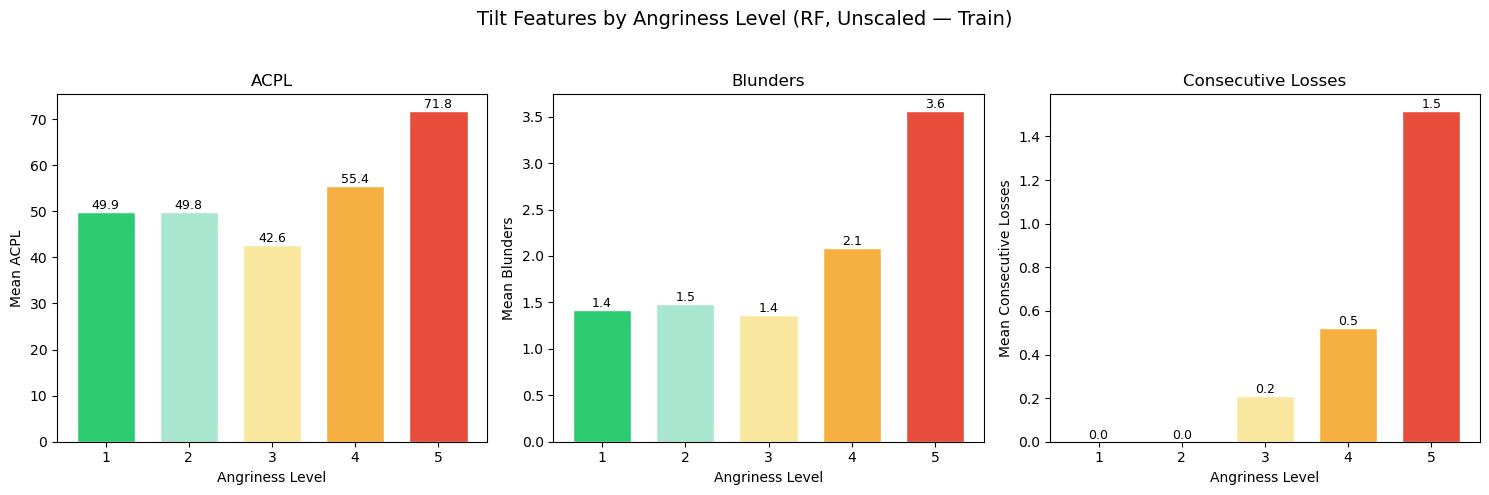

In [484]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (col, label) in zip(axes, [("acpl_player", "ACPL"),
                                   ("blunder_cnt_player", "Blunders"),
                                   ("consecutive_losses_pregame", "Consecutive Losses")]):
    means = raw_check.groupby("_angriness")[col].mean()
    bars = ax.bar(means.index, means.values,
                  color=[LEVEL_COLORS[i - 1] for i in means.index],
                  edgecolor="white", width=0.7)
    ax.set_xlabel("Angriness Level")
    ax.set_ylabel(f"Mean {label}")
    ax.set_title(label)
    ax.set_xticks(means.index)
    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f"{val:.1f}", ha="center", va="bottom", fontsize=9)

fig.suptitle("Tilt Features by Angriness Level (RF, Unscaled — Train)", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(PLOT_DIR / "v3_sanity_check_by_level.png", dpi=150)
plt.show()

## Step 4 — Evaluation

### 4a. Surrogate generalization (in-sample)

How faithfully the Random Forest reproduces the Isolation Forest's labels on held-out data.
This measures *surrogate fidelity*, **not** real tilt-detection accuracy — the labels are
synthetic. The Spearman columns are an in-sample sanity check only (they use IF inputs).

The Random Forest is regularized (`max_depth=9`, `min_samples_leaf=9`, `min_samples_split=10`)
so it acts as a faithful **surrogate** to the Isolation Forest rather than memorizing — the
train/val/test accuracy gap below confirms healthy generalization. Below the table we also run
a **tilt-ordering sanity check** (tilted games 4–5 must show higher ACPL / blunders /
consecutive losses than calm games 1–2) and plot per-split accuracy and Spearman diagnostics.

In [485]:
def eval_split(feat, raw):
    pred = rf.predict(raw[FEATURE_ORDER].values)
    y_if = np.array([score_to_angriness(s, bin_edges)
                     for s in if_model.decision_function(feat[FEATURE_ORDER].values)])
    return pred, accuracy_score(y_if, pred), f1_score(y_if, pred, average="weighted")

rows = []
preds = {}
for name, (f, r) in {"train": (feat_train, raw_train), "val": (feat_val, raw_val), "test": (feat_test, raw_test)}.items():
    p, acc, f1 = eval_split(f, r)
    preds[name] = p
    rho_acpl = spearmanr(p.astype(float), r["acpl_player"].values).correlation
    rows.append({"split": name, "n": len(r), "accuracy": round(acc, 4),
                 "f1_weighted": round(f1, 4), "rho_acpl": round(rho_acpl, 4)})
pd.DataFrame(rows).set_index("split")

,n,accuracy,f1_weighted,rho_acpl
split,,,,
train,14683,0.7432,0.7447,0.0911
val,4040,0.7139,0.7164,0.2031
test,5050,0.7022,0.7041,0.2177


In [486]:
# Tilt-ordering sanity check on the TEST set: tilted games (4-5) should show higher
# ACPL / blunders / consecutive losses than calm games (1-2). Uses the eval `preds`.
test_check = raw_test.copy()
test_check["_angriness"] = preds["test"]

calm = test_check[test_check["_angriness"].isin([1, 2])]
tilted = test_check[test_check["_angriness"].isin([4, 5])]

checks = {
    "ACPL higher when tilted": tilted["acpl_player"].mean() > calm["acpl_player"].mean(),
    "Blunders higher when tilted": tilted["blunder_cnt_player"].mean() > calm["blunder_cnt_player"].mean(),
    "Consecutive losses higher when tilted": tilted["consecutive_losses_pregame"].mean() > calm["consecutive_losses_pregame"].mean(),
}

all_pass = all(checks.values())
print(f"Tilt-ordering validation (test set): {'PASS' if all_pass else 'FAIL'}\n")
for check, result in checks.items():
    print(f"  {'PASS' if result else 'FAIL'} - {check}")

Tilt-ordering validation (test set): PASS

  PASS - ACPL higher when tilted
  PASS - Blunders higher when tilted
  PASS - Consecutive losses higher when tilted


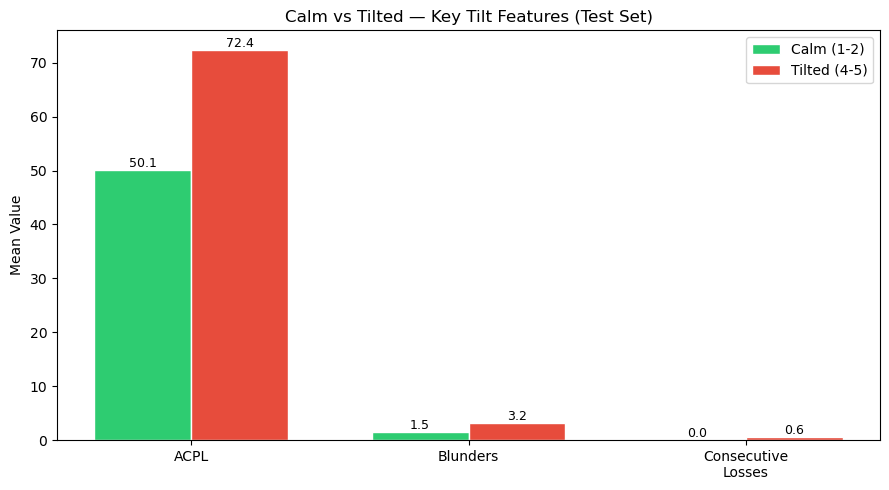

In [487]:
compare_cols = ["acpl_player", "blunder_cnt_player", "consecutive_losses_pregame"]
compare_labels = ["ACPL", "Blunders", "Consecutive\nLosses"]

calm_means = calm[compare_cols].mean()
tilted_means = tilted[compare_cols].mean()

x = np.arange(len(compare_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width / 2, calm_means.values, width, label="Calm (1-2)", color="#2ecc71", edgecolor="white")
bars2 = ax.bar(x + width / 2, tilted_means.values, width, label="Tilted (4-5)", color="#e74c3c", edgecolor="white")

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(compare_labels)
ax.set_ylabel("Mean Value")
ax.set_title("Calm vs Tilted — Key Tilt Features (Test Set)")
ax.legend()
fig.tight_layout()
fig.savefig(PLOT_DIR / "v3_calm_vs_tilted.png", dpi=150)
plt.show()

In [488]:
COMPOSITE_COLS = ["acpl_player", "blunder_cnt_player", "consecutive_losses_pregame"]
SHORT_NAMES = {"acpl_player": "ACPL", "blunder_cnt_player": "Blunders",
               "consecutive_losses_pregame": "ConsLoss"}

diag_results = []
for name, feat, raw in [("train", feat_train, raw_train),
                        ("val", feat_val, raw_val),
                        ("test", feat_test, raw_test)]:
    pred = preds[name]
    y_if = np.array([score_to_angriness(s, bin_edges)
                     for s in if_model.decision_function(feat[FEATURE_ORDER].values)])
    acc = round(float(accuracy_score(y_if, pred)), 4)
    f1 = round(float(f1_score(y_if, pred, average="weighted")), 4)
    spearman = {col: round(float(spearmanr(pred.astype(float), raw[col].values).correlation), 4)
                for col in COMPOSITE_COLS}
    diag_results.append({"name": name, "n": len(raw), "accuracy": acc, "f1": f1, "spearman": spearman})

print("Diagnostics computed for all 3 splits.")
for r in diag_results:
    rho_str = " ".join(f"{SHORT_NAMES[c]}rho={r['spearman'][c]:.3f}" for c in COMPOSITE_COLS)
    print(f"  {r['name']:>5}: acc={r['accuracy']:.4f} f1={r['f1']:.4f} {rho_str}")

Diagnostics computed for all 3 splits.
  train: acc=0.7432 f1=0.7447 ACPLrho=0.091 Blundersrho=0.195 ConsLossrho=0.453
    val: acc=0.7139 f1=0.7164 ACPLrho=0.203 Blundersrho=0.302 ConsLossrho=0.414
   test: acc=0.7022 f1=0.7041 ACPLrho=0.218 Blundersrho=0.318 ConsLossrho=0.395


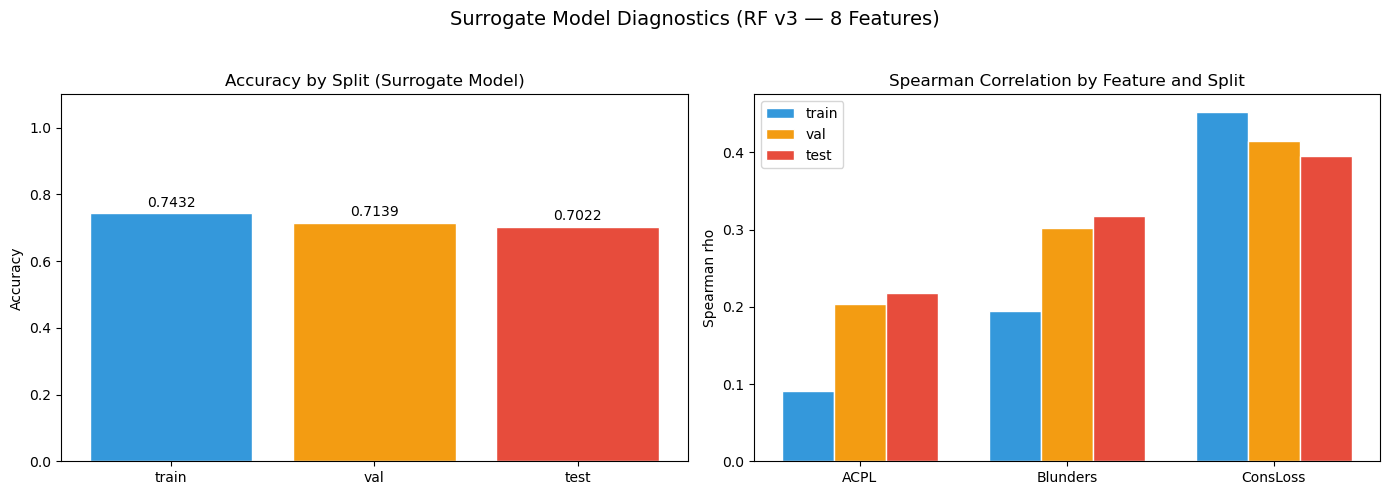

In [489]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
split_names = [r["name"] for r in diag_results]
colors_split = ["#3498db", "#f39c12", "#e74c3c"]

acc_values = [r["accuracy"] for r in diag_results]
axes[0].bar(split_names, acc_values, color=colors_split, edgecolor="white")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy by Split (Surrogate Model)")
axes[0].set_ylim(0, 1.1)
for i, v in enumerate(acc_values):
    axes[0].text(i, v + 0.02, f"{v:.4f}", ha="center", fontsize=10)

x = np.arange(len(COMPOSITE_COLS))
width = 0.25
for i, r in enumerate(diag_results):
    rhos = [r["spearman"][col] for col in COMPOSITE_COLS]
    axes[1].bar(x + i * width, rhos, width, label=r["name"], color=colors_split[i], edgecolor="white")
axes[1].set_xticks(x + width)
axes[1].set_xticklabels([SHORT_NAMES[c] for c in COMPOSITE_COLS])
axes[1].set_ylabel("Spearman rho")
axes[1].set_title("Spearman Correlation by Feature and Split")
axes[1].legend()

fig.suptitle(f"Surrogate Model Diagnostics (RF v3 — {len(FEATURE_ORDER)} Features)", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(PLOT_DIR / "v3_overfitting_diagnostics.png", dpi=150)
plt.show()

### 4b. External validity (non-circular)

The real question: does a high-angriness game predict a **worse next game**? We take each
test game's prediction and correlate it with the player's **next-game** rating change
(`elo_diff` of game N+1), sorted per player by time. Because `elo_diff` is **not** an
`IF_FEATURES` input, this is an independent signal — the tilt hypothesis predicts **rho < 0**
(angrier now → rating drop next game) and higher angriness before a next-game loss.

This is a deliberately *weak* signal (single-game rating change is noisy), but it is the
correct *method*: validation against data the label generator never saw.

In [490]:
val = pd.read_csv(PROCESSED / "raw_validated.csv").sort_values(["username", "created_at"])
val["next_elo_diff"] = val.groupby("username")["elo_diff"].shift(-1)
nxt = {(g, u): e for g, u, e in zip(val["game_id"], val["username"], val["next_elo_diff"]) if pd.notna(e)}

keys = list(zip(raw_test["game_id"], raw_test["username"]))
next_elo = np.array([nxt.get(k, np.nan) for k in keys], dtype=float)
ang_test = preds["test"].astype(float)
has_next = ~np.isnan(next_elo)

rho, pval = spearmanr(ang_test[has_next], next_elo[has_next])
loss = has_next & (next_elo < 0)
win = has_next & (next_elo >= 0)
mean_loss, mean_win = ang_test[loss].mean(), ang_test[win].mean()

print(f"n with a next game: {int(has_next.sum())}")
print(f"Spearman(angriness, next_elo_diff) = {rho:.4f}  (p={pval:.2g})")
print(f"Mean angriness | next is loss: {mean_loss:.3f}   | next not loss: {mean_win:.3f}")
print("Supports tilt hypothesis:", "YES" if (rho < 0 and mean_loss > mean_win) else "NO / weak")

n with a next game: 2555
Spearman(angriness, next_elo_diff) = -0.0854  (p=1.6e-05)
Mean angriness | next is loss: 3.420   | next not loss: 3.405
Supports tilt hypothesis: YES


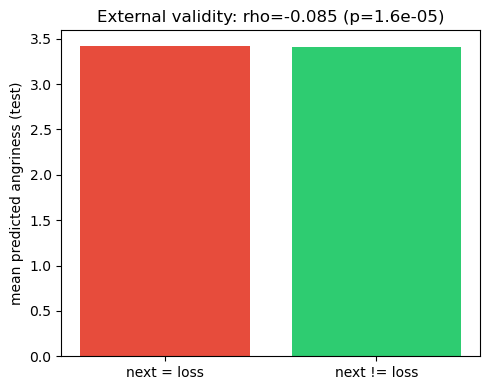

In [491]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["next = loss", "next != loss"], [mean_loss, mean_win], color=["#e74c3c", "#2ecc71"])
ax.set_ylabel("mean predicted angriness (test)")
ax.set_title(f"External validity: rho={rho:.3f} (p={pval:.1e})")
plt.tight_layout()
plt.show()

## Summary

- **Leak fixed:** every fitted transform (impute / IQR / scale) is now train-only; the
  Isolation Forest was already train-only, so labels were never leaked.
- **Honest framing:** surrogate accuracy (~0.72 test) measures RF↔IF fidelity, not real tilt
  accuracy — the labels are synthetic.
- **Non-circular evidence:** angriness shows a small but statistically significant negative
  correlation with the player's **next-game** rating change — independent of the label
  generator. It is weak, which we state plainly; the value is the *method*.
- **Next steps:** stronger external signals (rating change over the next *k* games, game
  aborts / rage-quits, deviation from the player's own baseline) would tighten the validity
  argument.

In [492]:
print(f"Pipeline v3 complete. Tilt-ordering validation {'PASSED' if all_pass else 'FAILED'}.")
print(f"\nModel: Semi-Supervised (IF + RF), {len(FEATURE_ORDER)} features (7 behavioral + ELO), unscaled RF input")
print(f"Split: {len(feat_train)} train / {len(feat_val)} val / {len(feat_test)} test")
print(f"\nTest accuracy (RF vs IF labels): {diag_results[2]['accuracy']:.4f}")
print(f"Generalization: Val {diag_results[1]['accuracy']:.4f} vs Test {diag_results[2]['accuracy']:.4f} "
      f"(gap {abs(diag_results[1]['accuracy'] - diag_results[2]['accuracy']):.4f})")
print(f"External validity: Spearman(angriness, next_elo_diff) = {rho:.4f} (p={pval:.2g})")

Pipeline v3 complete. Tilt-ordering validation PASSED.

Model: Semi-Supervised (IF + RF), 8 features (7 behavioral + ELO), unscaled RF input
Split: 14683 train / 4040 val / 5050 test

Test accuracy (RF vs IF labels): 0.7022
Generalization: Val 0.7139 vs Test 0.7022 (gap 0.0117)
External validity: Spearman(angriness, next_elo_diff) = -0.0854 (p=1.6e-05)
